# Eksperimen #3 — Augmentasi (train D2 diperbesar 3×)

**Perubahan dari meanstd:** train digabung dengan **2 salinan augmentasi** per file
(`yamnet_stats_d2_aug.npz`) → 1195 + 2390 = **3585**. Val & test **tetap asli**
(`yamnet_stats_d2.npz`). Fitur, head, recipe esf1 identik.

**Hipotesis:** keragaman training (noise/shift/gain) menaikkan generalisasi, khususnya
kelas lemah (ambulance 0.697, police 0.757 pada meanstd).

**Pembanding D2:** baseline 0.7639 · esf1 0.7725 · **meanstd 0.7983**.

In [1]:
import json
import random
from datetime import datetime
from pathlib import Path

import numpy as np
import pandas as pd
import tensorflow as tf
from sklearn.metrics import f1_score, accuracy_score, classification_report, confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.keras.utils.set_random_seed(SEED)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ML_DIR = ML = ROOT / "ml"

# --- muat cache asli (train/val/test) + augmentasi (train saja) ---
orig = np.load(ML / "cache" / "yamnet_stats_d2.npz", allow_pickle=True)
aug = np.load(ML / "cache" / "yamnet_stats_d2_aug.npz", allow_pickle=True)
emb_by_file = {fn: e for fn, e in zip(orig["filename"], orig["emb"])}

CLASSES = sorted(set(orig["label"]))
idx = {c: i for i, c in enumerate(CLASSES)}


def split_orig(name):
    df = pd.read_csv(ML / f"split_d2_{name}.csv")
    X = np.stack([emb_by_file[fn] for fn in df.filename]).astype(np.float32)
    y = df.label.map(idx).to_numpy()
    return X, y


X_tr_o, y_tr_o = split_orig("train")
X_va, y_va = split_orig("val")
X_te, y_te = split_orig("test")

# train diperbesar: asli + augmentasi
X_tr = np.concatenate([X_tr_o, aug["emb"].astype(np.float32)])
y_tr = np.concatenate([y_tr_o, np.array([idx[l] for l in aug["label"]])])

print(f"train asli      : {X_tr_o.shape}")
print(f"train + augment : {X_tr.shape}   (val {X_va.shape[0]}, test {X_te.shape[0]})")
print(f"kelas           : {CLASSES}")

train asli      : (1195, 2048)
train + augment : (3585, 2048)   (val 240, test 240)
kelas           : ['ambulance', 'firetruck', 'police', 'traffic']


## Standardisasi (statistik train, termasuk augmentasi)

In [2]:
mean = X_tr.mean(0, keepdims=True); std = X_tr.std(0, keepdims=True)
std = np.where(std < 1e-6, 1.0, std)
X_tr = (X_tr - mean) / std
X_va = (X_va - mean) / std
X_te = (X_te - mean) / std
print(f"standardisasi ok — max |mean kolom| = {np.abs(X_tr.mean(0)).max():.1e}")

standardisasi ok — max |mean kolom| = 4.3e-06


## Head + recipe esf1 (identik) & training

In [3]:
class ValMacroF1(tf.keras.callbacks.Callback):
    def __init__(self, X_val, y_val):
        super().__init__(); self.X_val, self.y_val = X_val, y_val
    def on_epoch_end(self, epoch, logs=None):
        logs = logs if logs is not None else {}
        p = self.model.predict(self.X_val, verbose=0).argmax(axis=1)
        logs["val_macro_f1"] = f1_score(self.y_val, p, average="macro")


model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(X_tr.shape[1],)),
    tf.keras.layers.Dense(256, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.3),
    tf.keras.layers.Dense(len(CLASSES), activation="softmax"),
])
model.compile(optimizer=tf.keras.optimizers.Adam(1e-3),
              loss="sparse_categorical_crossentropy", metrics=["accuracy"])

callbacks = [
    ValMacroF1(X_va, y_va),
    tf.keras.callbacks.EarlyStopping(monitor="val_macro_f1", mode="max",
                                     patience=20, restore_best_weights=True),
    tf.keras.callbacks.ReduceLROnPlateau(monitor="val_macro_f1", mode="max",
                                         factor=0.5, patience=8, min_lr=1e-5),
]
hist = model.fit(X_tr, y_tr, validation_data=(X_va, y_va),
                 epochs=200, batch_size=32, callbacks=callbacks, verbose=0)
best_epoch = int(np.argmax(hist.history["val_macro_f1"])) + 1
print(f"best_epoch={best_epoch} dari {len(hist.history['loss'])}")

best_epoch=7 dari 27


## Evaluasi

TEST macro-F1 : 0.7965   (meanstd 0.7983 · target 0.85)
TEST accuracy : 0.7958

              precision    recall  f1-score   support

   ambulance      0.736     0.672     0.703        58
   firetruck      0.686     0.857     0.762        56
      police      0.787     0.727     0.756        66
     traffic      1.000     0.933     0.966        60

    accuracy                          0.796       240
   macro avg      0.802     0.798     0.797       240
weighted avg      0.804     0.796     0.797       240



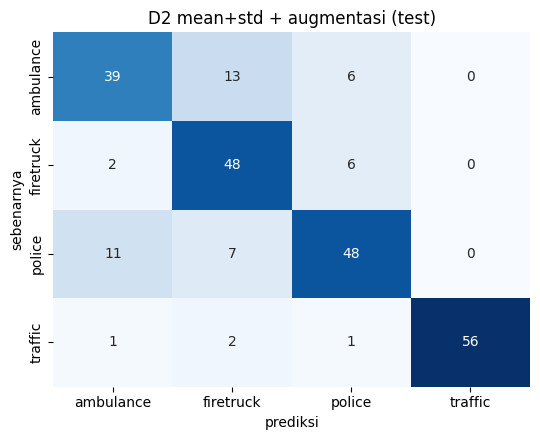

In [4]:
y_pred = model.predict(X_te, verbose=0).argmax(axis=1)
macro_f1 = f1_score(y_te, y_pred, average="macro")
acc = accuracy_score(y_te, y_pred)
print(f"TEST macro-F1 : {macro_f1:.4f}   (meanstd 0.7983 · target 0.85)")
print(f"TEST accuracy : {acc:.4f}\n")
print(classification_report(y_te, y_pred, target_names=CLASSES, digits=3))

cm = confusion_matrix(y_te, y_pred)
plt.figure(figsize=(5.5, 4.5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=CLASSES, yticklabels=CLASSES, cbar=False)
plt.xlabel("prediksi"); plt.ylabel("sebenarnya"); plt.title("D2 mean+std + augmentasi (test)")
plt.tight_layout()
fig_dir = ROOT / "figures" / "train_d2"; fig_dir.mkdir(parents=True, exist_ok=True)
plt.savefig(fig_dir / "confusion_matrix_aug.png", bbox_inches="tight")
plt.show()

## Simpan artefak + catat + bandingkan

In [5]:
exp_id = "d2_yamnet_mlp_meanstd_aug"
art = ML / "artifacts" / exp_id; art.mkdir(parents=True, exist_ok=True)
model.save(art / "model.keras")
(art / "metrics.json").write_text(json.dumps({
    "test_macro_f1": float(macro_f1), "test_accuracy": float(acc),
    "per_class_f1": dict(zip(CLASSES, f1_score(y_te, y_pred, average=None).tolist())),
    "best_epoch": best_epoch, "feature": "yamnet_meanstd_2048",
    "augment": "noise+shift+gain x2", "n_train": int(len(y_tr)),
}, indent=2))
pd.DataFrame([{
    "timestamp": datetime.now().isoformat(timespec="seconds"),
    "exp_id": exp_id, "dataset": "d2", "backbone": "yamnet",
    "head": "mlp_256_128_meanstd_aug", "n_train": len(y_tr), "n_test": len(y_te),
    "best_epoch": best_epoch, "test_macro_f1": round(macro_f1, 4),
    "test_accuracy": round(acc, 4),
}]).to_csv(ML / "experiments.csv", mode="a", header=False, index=False)

# perbandingan per-kelas vs meanstd
prev = {"ambulance": 0.697, "firetruck": 0.764, "police": 0.757, "traffic": 0.975}
now = dict(zip(CLASSES, f1_score(y_te, y_pred, average=None)))
print(f"{'kelas':10s} {'meanstd':>8s} {'aug':>8s} {'Δ':>8s}")
for c in CLASSES:
    print(f"{c:10s} {prev[c]:>8.3f} {now[c]:>8.3f} {now[c]-prev[c]:>+8.3f}")

print("\n--- experiments.csv (D2) ---")
df = pd.read_csv(ML / "experiments.csv")
print(df[df.dataset == "d2"][["exp_id", "test_macro_f1", "test_accuracy"]].to_string(index=False))

kelas       meanstd      aug        Δ
ambulance     0.697    0.703   +0.006
firetruck     0.764    0.762   -0.002
police        0.757    0.756   -0.001
traffic       0.975    0.966   -0.009

--- experiments.csv (D2) ---
                   exp_id  test_macro_f1  test_accuracy
            d2_yamnet_mlp         0.7639         0.7667
       d2_yamnet_mlp_esf1         0.7725         0.7750
    d2_yamnet_mlp_meanstd         0.7983         0.8000
d2_yamnet_mlp_meanstd_aug         0.7965         0.7958


---

**Interpretasi:** kalau ambulance/police naik & macro-F1 mendekati/menembus 0.85, augmentasi
berhasil. Kalau flat, augmentasi offline 2× tak cukup → pertimbangkan fine-tune YAMNet
(Kaggle GPU) sebagai lever terakhir. (Lihat decision gate di plan.)